## Tahap 1: Load Dataset

In [112]:
# Load Dataset
import pandas as pd

from google.colab import files
uploaded = files.upload()



Saving dataset_tugas1_preprocessing.csv to dataset_tugas1_preprocessing (8).csv


In [113]:
df = pd.read_csv('dataset_tugas1_preprocessing.csv')

## Tahap 2:Eksplorasi Awal (EDA)

In [ ]:
# mengecek struktur data
df.info()
df.shape

# Missing Value
# Nilai_Akhir 29 missing
# Umur ada 9 missing

In [114]:
df.isnull().sum()

,0
ID,0
Nama,0
Jenis_Kelamin,0
Prodi,0
Status,0
Nilai_Akhir,29
Tanggal_Ujian,0
Umur,9


In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
df.describe(include='object')

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian
count,99,99,99,99,99,70,99
unique,99,10,2,4,4,5,97
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/03/31
freq,1,15,50,28,29,17,2


## Tahap 3: Menangani Missing Values


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB


In [118]:
df['Nilai_Akhir'].unique()

# menghapus baris dari nilai akhir yang memiliki Nan
df = df.dropna(subset=['Nilai_Akhir'])

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 1 to 97
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             70 non-null     object 
 1   Nama           70 non-null     object 
 2   Jenis_Kelamin  70 non-null     object 
 3   Prodi          70 non-null     object 
 4   Status         70 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  70 non-null     object 
 7   Umur           64 non-null     float64
dtypes: float64(1), object(7)
memory usage: 4.9+ KB


In [121]:
df['Tanggal_Ujian'].unique()
df['Status'].unique()

array(['Lulus', 'Aktif', 'DO', 'Cuti'], dtype=object)

## Tahap 4: Komversi tipe data tanggal Ujian menjadi Datetime

In [122]:
# konversi tipe data Tanggal_Ujian
df['Tanggal_Ujian'] = pd.to_datetime(
    df['Tanggal_Ujian'],
    dayfirst=True,
    errors='coerce'
)

In [123]:
# mengisi kolom Tanggal_ujian yang gagal di parse menjadi datetime dengan median
df['Tanggal_Ujian'] = df['Tanggal_Ujian'].fillna(df['Tanggal_Ujian'].median())

In [124]:
df['Umur'] = df['Umur'].fillna(df['Umur'].median())

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 1 to 97
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             70 non-null     object        
 1   Nama           70 non-null     object        
 2   Jenis_Kelamin  70 non-null     object        
 3   Prodi          70 non-null     object        
 4   Status         70 non-null     object        
 5   Nilai_Akhir    70 non-null     object        
 6   Tanggal_Ujian  70 non-null     datetime64[ns]
 7   Umur           70 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 4.9+ KB


## Tahap 5: Encoding label dan Kategori Data

In [126]:
# Drop kolom yang tidak kepakai
df = df.drop(columns=['ID','Nama'])

# Mapping ordinal

mapping_nilai = {'A':90,'B':80,'C':70,'D':60,'E':50}
df['Nilai_Akhir'] = df['Nilai_Akhir'].map(mapping_nilai)

In [127]:
# Feature Engeineering kolom Tanggal

df['tahun'] = df['Tanggal_Ujian'].dt.year
df['bulan'] = df['Tanggal_Ujian'].dt.month


In [128]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder untuk kolom status
le = LabelEncoder()

df['Status'] = le.fit_transform(df['Status'])

print("SETELAH LABEL ENCODING")
print(df.head())

SETELAH LABEL ENCODING
  Jenis_Kelamin            Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur  \
1     Perempuan  Teknik Komputer       3           50    2020-11-12  28.0   
3     Perempuan  Teknik Komputer       0           60    2020-12-02  18.0   
4     Perempuan     Data Science       0           70    2020-05-01  26.0   
5     Perempuan  Teknik Komputer       0           70    2020-12-02  20.0   
6     Laki-laki     Data Science       2           70    2020-12-02  21.0   

   tahun  bulan  
1   2020     11  
3   2020     12  
4   2020      5  
5   2020     12  
6   2020     12  


In [130]:
# One Hot Encoding
X = pd.get_dummies(
    df.drop(columns=['Status']),
    columns=['Jenis_Kelamin','Prodi'],
    dtype=int
)
X

,Nilai_Akhir,Tanggal_Ujian,Umur,tahun,bulan,Jenis_Kelamin_Laki-laki,Jenis_Kelamin_Perempuan,Prodi_Data Science,Prodi_Informatika,Prodi_Sistem Informasi,Prodi_Teknik Komputer
1,50,2020-11-12,28.0,2020,11,0,1,0,0,0,1
3,60,2020-12-02,18.0,2020,12,0,1,0,0,0,1
4,70,2020-05-01,26.0,2020,5,0,1,1,0,0,0
5,70,2020-12-02,20.0,2020,12,0,1,0,0,0,1
6,70,2020-12-02,21.0,2020,12,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
93,60,2020-12-02,26.0,2020,12,0,1,0,0,0,1
94,60,2020-12-02,21.0,2020,12,1,0,0,0,0,1
95,70,2020-12-02,20.0,2020,12,1,0,0,0,1,0
96,60,2020-11-01,23.0,2020,11,1,0,1,0,0,0


## Tahap 6: Split Data


In [131]:
# buat target yang sudah kita label encode
y = df['Status']

In [132]:
# split data 80% data training dan 20% data test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [133]:
# cek hasil
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (56, 11)
X_test : (14, 11)
y_train: (56,)
y_test : (14,)


## Tahap 7: Normalisasi dan Standardisasi


In [140]:
from sklearn.preprocessing import StandardScaler

print(X.columns)

cols = ['Nilai_Akhir','Umur']
scaler = StandardScaler()

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

Index(['Nilai_Akhir', 'Umur', 'tahun', 'bulan', 'Jenis_Kelamin_Laki-laki',
       'Jenis_Kelamin_Perempuan', 'Prodi_Data Science', 'Prodi_Informatika',
       'Prodi_Sistem Informasi', 'Prodi_Teknik Komputer'],
      dtype='object')


In [141]:
print(X_train[cols].describe())

        Nilai_Akhir          Umur
count  5.600000e+01  5.600000e+01
mean  -7.930164e-18 -7.930164e-18
std    1.009050e+00  1.009050e+00
min   -1.488002e+00 -1.567188e+00
25%   -7.505850e-01 -9.513108e-01
50%   -1.316816e-02 -2.749453e-02
75%    7.242487e-01  6.653677e-01
max    1.461666e+00  2.128077e+00


## Tahap 7: Visualisasi

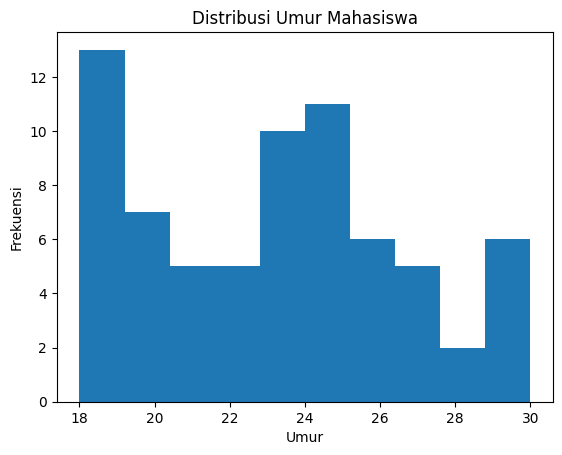

In [142]:
# visual kolom Umur
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Umur'], bins=10)
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

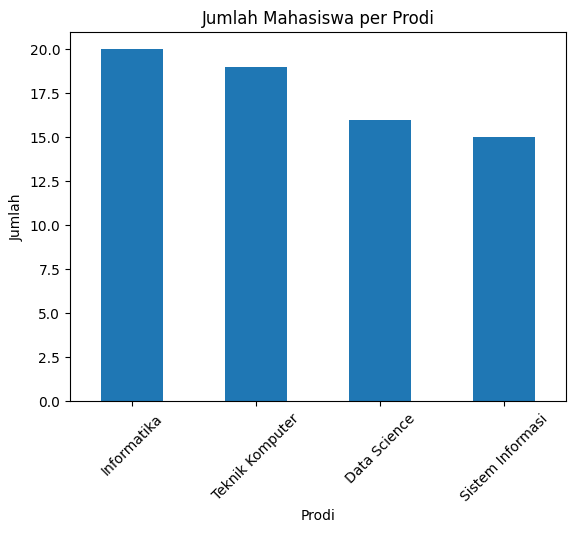

In [144]:
# Grafik Batang Jumlah Mahasiswa per Prodi
prodi_count = df['Prodi'].value_counts()

plt.figure()
prodi_count.plot(kind='bar')
plt.title('Jumlah Mahasiswa per Prodi')
plt.xlabel('Prodi')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()